In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
import copy
import random

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [3]:
DATA_DIR = r'/home/pcdm/Desktop/indoor/Images'
model_algo="alexnet"

In [4]:

transform=transforms.Compose([
    transforms.Resize((229,229)),    
    transforms.ToTensor() 
])

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform,decision_mode=False)

generator = torch.Generator()
generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)

train_size = int(size - valid_size )

trainset, validset= random_split(images, (train_size, valid_size), generator=generator)


In [6]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [7]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_3.pth')

In [8]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.20796885163965664, 0.9527048655569782)

In [9]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(1.4362402554510802, 0.6139564660691421)

In [10]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [11]:
each_accu=2*p*r/(p+r)
each_accu

airport_inside    0.963580
artstudio         0.926407
auditorium        0.955224
bakery            0.956661
bar               0.969050
                    ...   
tv_studio         0.919708
videostore        0.931818
waitingroom       0.905830
warehouse         0.971429
winecellar        0.988180
Length: 67, dtype: float64

In [12]:
targetF=[x  for x in each_accu.nsmallest(35).index.map(trainset.dataset.classess)]
targetF

[49,
 56,
 50,
 40,
 64,
 20,
 5,
 62,
 35,
 60,
 24,
 22,
 41,
 1,
 32,
 31,
 9,
 17,
 55,
 63,
 38,
 8,
 36,
 29,
 37,
 47,
 42,
 54,
 7,
 21,
 43,
 45,
 2,
 3,
 6]

In [13]:
#將資料切分成true and false
def split_data(model_0,data_dl,split_mode):
    model_0.eval()
    indexF=[]
    indexT=[]
    with torch.no_grad():
        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
            criterion = nn.CrossEntropyLoss(reduction='none')
            loss = criterion(out, target)
            softmax = torch.softmax(out, dim=1)
            # print(loss)
            for idx,loss,t,pred ,softmax in zip(idx,loss,target,y_pred_tag,softmax):
                if(split_mode[0]=='loss'):    
                    if(loss>split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    # elif(loss>split_mode[1] and loss<split_mode[0]):
                    #    indexF.append(idx.cpu().numpy().item())  
                    #    indexT.append(idx.cpu().numpy().item())
                    else:
                        indexT.append(idx.cpu().numpy().item())  
                elif(split_mode=='TandF'):
                    
                    if(t!=pred):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())
                     
                   
                elif(split_mode[0]=='softmax'):
                 
                    if(softmax.max()<split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())
                        # if(softmax.max()<split_mode[2]):
                        #     indexF.append(idx.cpu().numpy().item())

                elif(split_mode[0]=='classaccu'):
                    if(t in split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                        if(t in [4,54,2,20]):
                            indexT.append(idx.cpu().numpy().item()) 
                            
                    else:
                        indexT.append(idx.cpu().numpy().item()) 
                        if(t in [4,54,2,20]):
                            indexF.append(idx.cpu().numpy().item()) 
                            
            torch.cuda.empty_cache() 
        return indexF,indexT

In [14]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('TandF')
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(591, 11905)

In [15]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(1206, 1918)

In [16]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

In [17]:
#decision set
def decision_split(data_dl,model_0):
    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        model_0.eval()   

        for data, target,idx in data_dl:

            data,target=data.to(device),target.to(device)
            out= model_0(data)
            softmax = torch.softmax(out, dim=1)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for i,d,t in zip(idx,data,target):
                # if(t!=0):
                flat_true.append(int(data_dl.dataset.dataset.flag[i]))
                flat_data.append(d.cpu().numpy()) 
            
    return flat_data,flat_true

In [18]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [19]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [20]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,class_weight=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    elif(data_name=='T'or data_name=='F' or data_name=='F_f'or data_name=='T_f'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
        model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]


    if(data_name=="decision"):
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)

    elif(data_name=='F'):
        optim = torch.optim.Adam(model.classifier[6].parameters(), lr=1e-4)
    else:   
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)

    criterion = nn.CrossEntropyLoss()
    model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
   
    torch.cuda.empty_cache() 
    return model


Epoch=0,train_loss=0.22456790658522507,train_accu=0.9027688860435339
Epoch=0,valid_loss=1.1042384125969626,valid_accu=0.6005121638924455
0
Epoch=1,train_loss=0.04497914361170041,train_accu=0.9858354673495519
Epoch=1,valid_loss=1.9759708177417554,valid_accu=0.6120358514724712
0
Epoch=2,train_loss=0.021887060744323016,train_accu=0.995758642765685
Epoch=2,valid_loss=2.5566896751198667,valid_accu=0.6193982074263764
0
Epoch=3,train_loss=0.019383247985965756,train_accu=0.9950384122919335
Epoch=3,valid_loss=2.6233388477037263,valid_accu=0.6222791293213829
0
Epoch=4,train_loss=0.020005098857626077,train_accu=0.9963188220230473
Epoch=4,valid_loss=3.0390525859388284,valid_accu=0.6216389244558259
Epoch=5,train_loss=0.010331286792114208,train_accu=0.9975192061459667
Epoch=5,valid_loss=3.402937395166649,valid_accu=0.6200384122919335
Epoch=6,train_loss=0.01645644324347669,train_accu=0.9972791293213829
Epoch=6,valid_loss=3.156204102744519,valid_accu=0.6216389244558259
Epoch=7,train_loss=0.00948543048

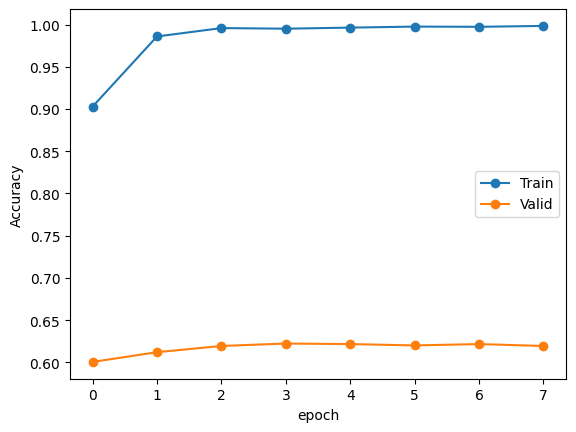

In [21]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70)

Epoch=0,train_loss=0.19502178539061613,train_accu=0.9528769424611507
Epoch=0,valid_loss=0.3773681690160873,valid_accu=0.8879040667361835
0
Epoch=1,train_loss=0.08153299655980328,train_accu=0.9833683326333473
Epoch=1,valid_loss=0.34589121305035103,valid_accu=0.8826903023983316
Epoch=2,train_loss=0.03449396689582115,train_accu=0.9942041159176817
Epoch=2,valid_loss=0.3179225415706137,valid_accu=0.8852971845672576
Epoch=3,train_loss=0.019443367672501512,train_accu=0.9972280554388913
Epoch=3,valid_loss=0.306140668853356,valid_accu=0.9009384775808134
0
Epoch=4,train_loss=0.011880673554203323,train_accu=0.9985720285594288
Epoch=4,valid_loss=0.30774494374755523,valid_accu=0.90563086548488
0
Epoch=5,train_loss=0.012555611141398393,train_accu=0.997480050398992
Epoch=5,valid_loss=0.32371865761416796,valid_accu=0.892075078206465
Epoch=6,train_loss=0.007982890581909558,train_accu=0.9985720285594288
Epoch=6,valid_loss=0.29862377852419,valid_accu=0.9035453597497393
Epoch=7,train_loss=0.00754009534513

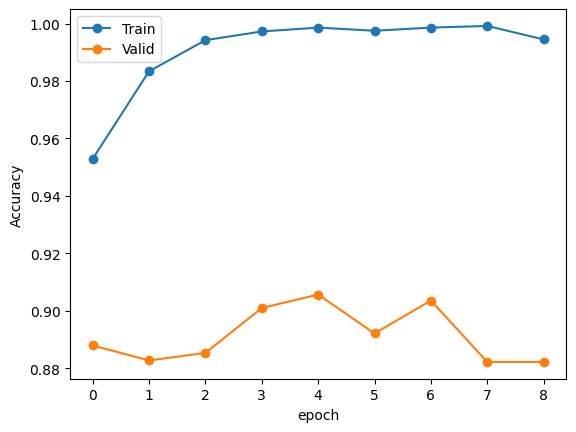

In [22]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=3.0278125878316295,train_accu=0.22673434856175972
Epoch=0,valid_loss=4.016562982182795,valid_accu=0.1044776119402985
0
Epoch=1,train_loss=2.3976829185098563,train_accu=0.37055837563451777
Epoch=1,valid_loss=3.771022775675329,valid_accu=0.15754560530679934
0
Epoch=2,train_loss=1.978409753434751,train_accu=0.5042301184433164
Epoch=2,valid_loss=3.573157830815608,valid_accu=0.1824212271973466
0
Epoch=3,train_loss=1.6713441110101044,train_accu=0.626057529610829
Epoch=3,valid_loss=3.4719292429549182,valid_accu=0.19651741293532338
0
Epoch=4,train_loss=1.438494201642406,train_accu=0.7072758037225042
Epoch=4,valid_loss=3.416406007943857,valid_accu=0.20149253731343283
0
Epoch=5,train_loss=1.2496374506635715,train_accu=0.7681895093062606
Epoch=5,valid_loss=3.380240658622476,valid_accu=0.21227197346600332
0
Epoch=6,train_loss=1.0980213981392823,train_accu=0.8206429780033841
Epoch=6,valid_loss=3.376446516755011,valid_accu=0.20978441127694858
Epoch=7,train_loss=0.9766912879879301,

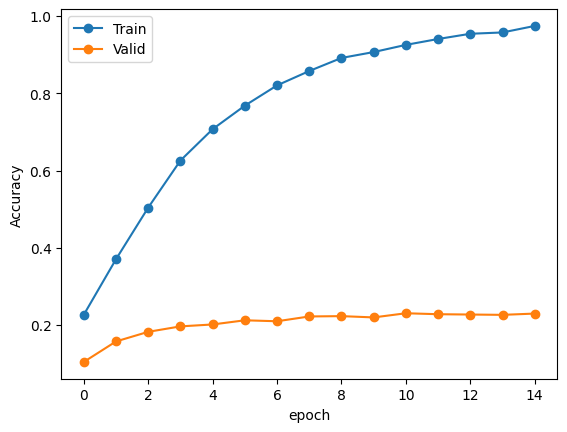

In [23]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [24]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.018756953129788118, 0.9944782330345711)

In [25]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(2.6233388477037263, 0.6222791293213829)

In [26]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.011880673755097982, 0.9985720285594288)

In [27]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.7087484020267041, 0.9255499153976311)

In [28]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.307744947197042, 0.90563086548488)

In [29]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(3.412496759326106, 0.23051409618573798)

In [30]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum_all=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum_all

(0.04483897182744631, 0.995118437900128, 591)

In [31]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum_all=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum_all

(1.5063139418481102, 0.6450064020486556, 1206)

In [32]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.07303144409089908, 0.9891965428937259, 711, 11785)

In [33]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(1.9089462328201372, 0.6286811779769527, 98, 3026)

In [34]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [35]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'split_mode = {split_mode}')
df

split_mode = TandF


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.207969,0.952705,1.436240,0.613956
1,Model_Decision,0.018757,0.994478,0.018757,0.622279
2,Model_T,0.011881,0.998572,0.307745,0.905631
3,Model_F,0.708748,0.925550,3.412497,0.230514
4,Total_Model,0.073031,0.989197,1.908946,0.628681
5,Total_Model_without_decision,0.044839,0.995118,1.506314,0.645006


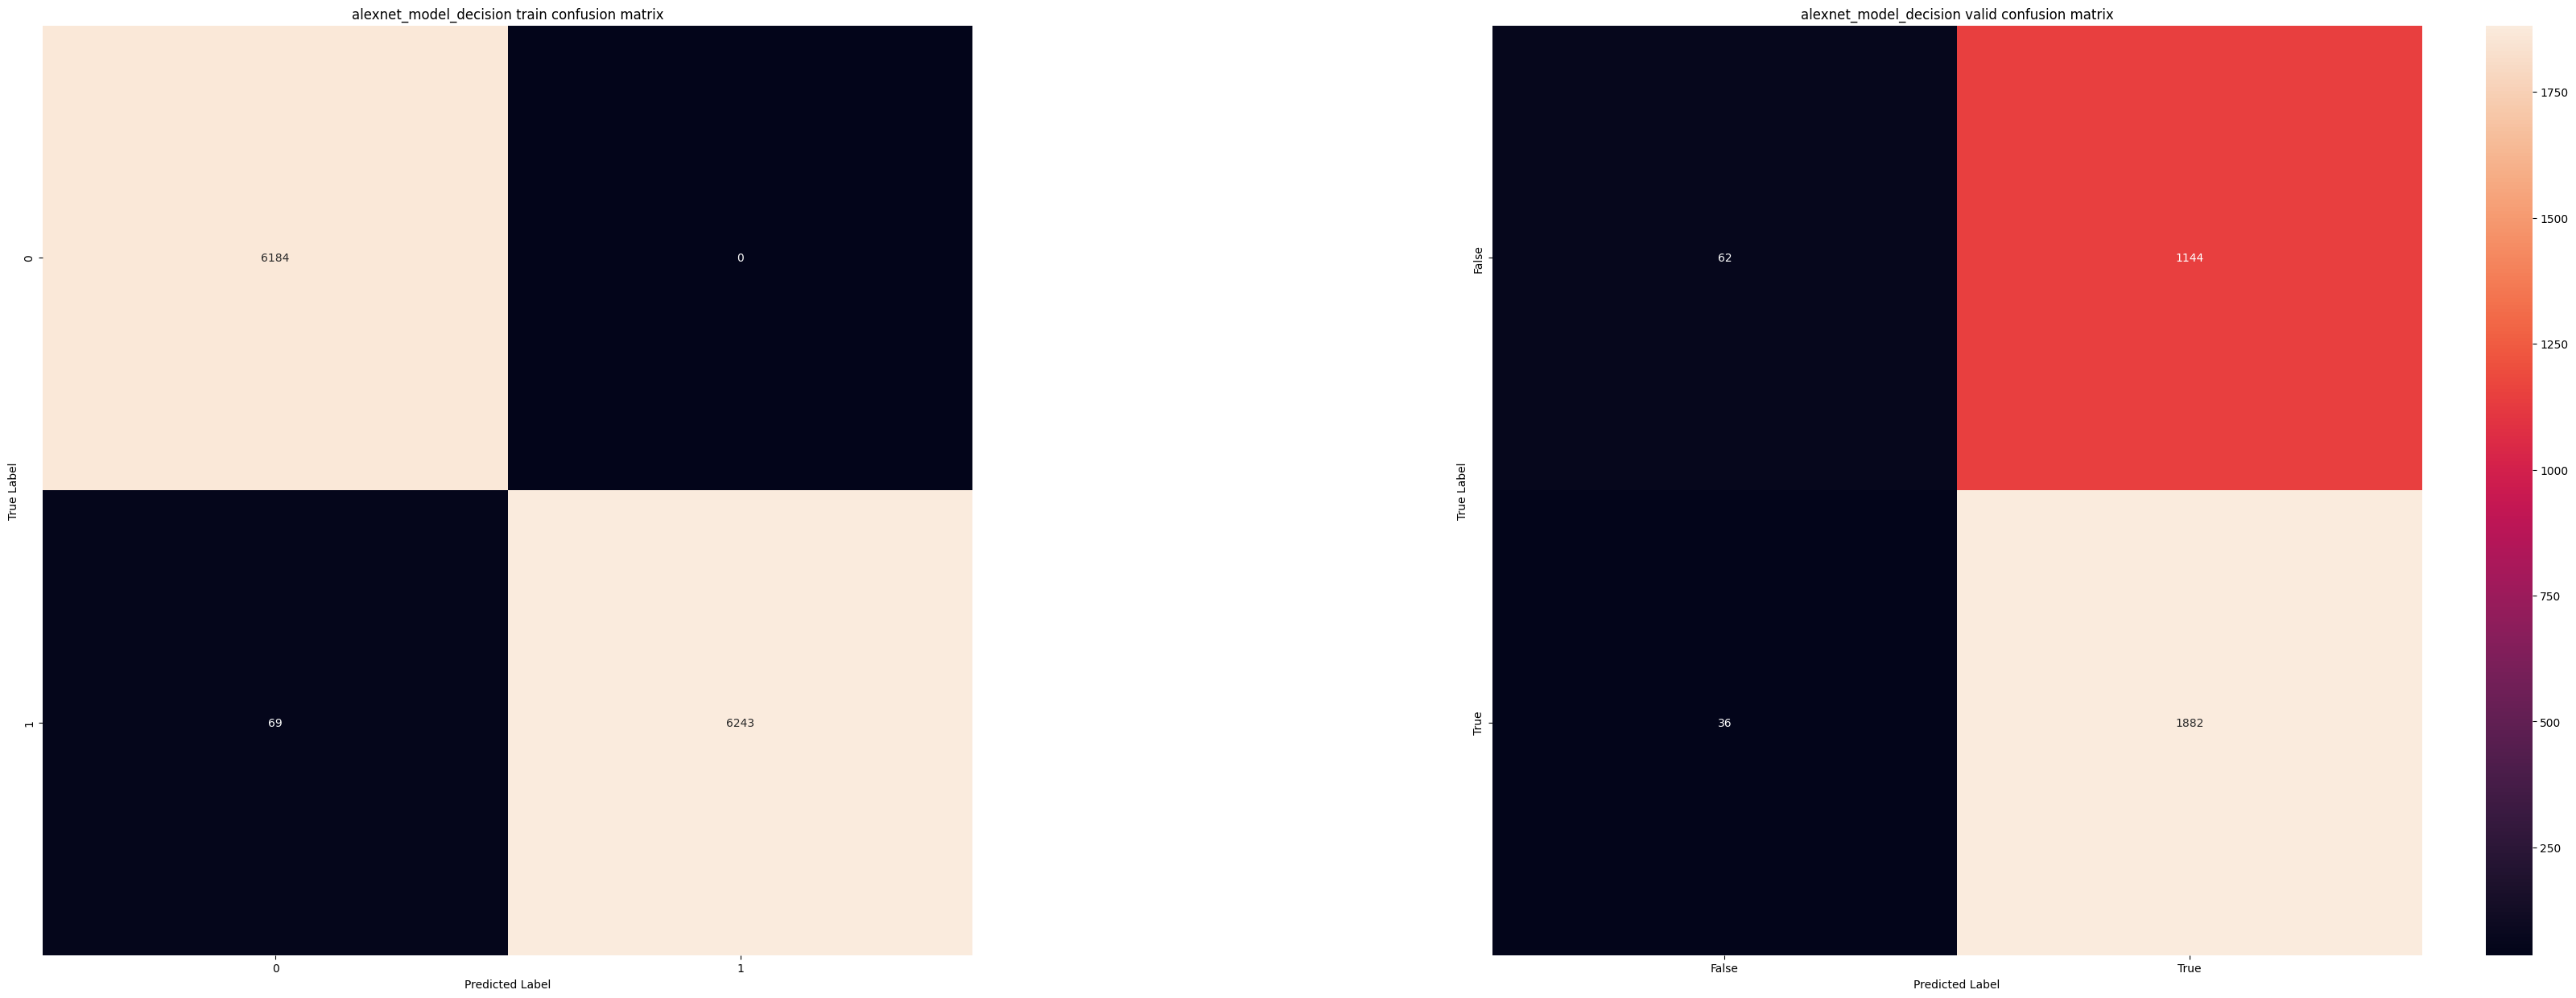

In [36]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

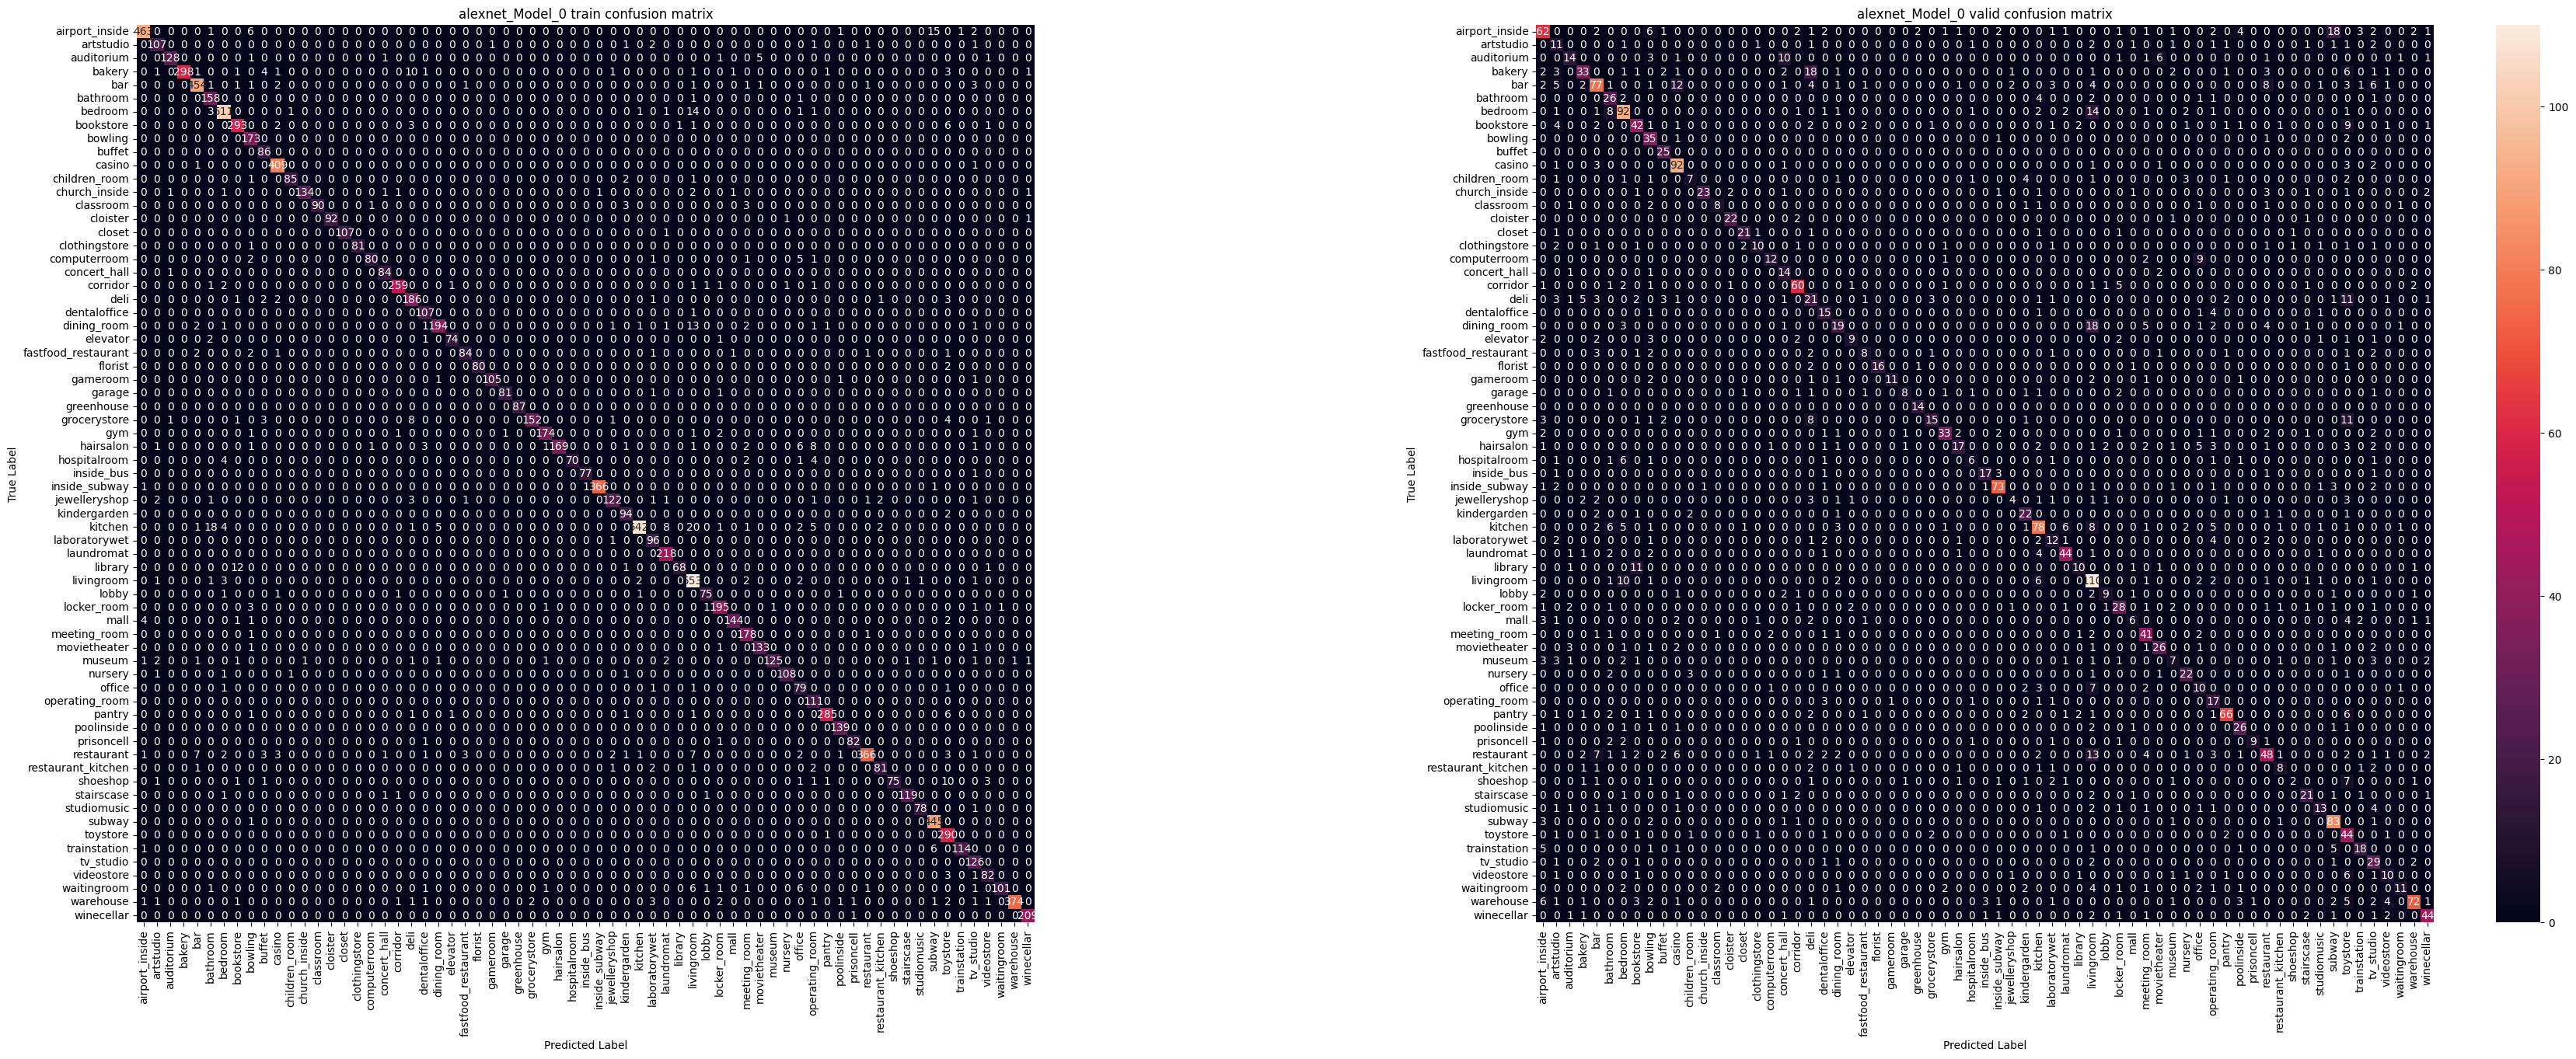

In [37]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

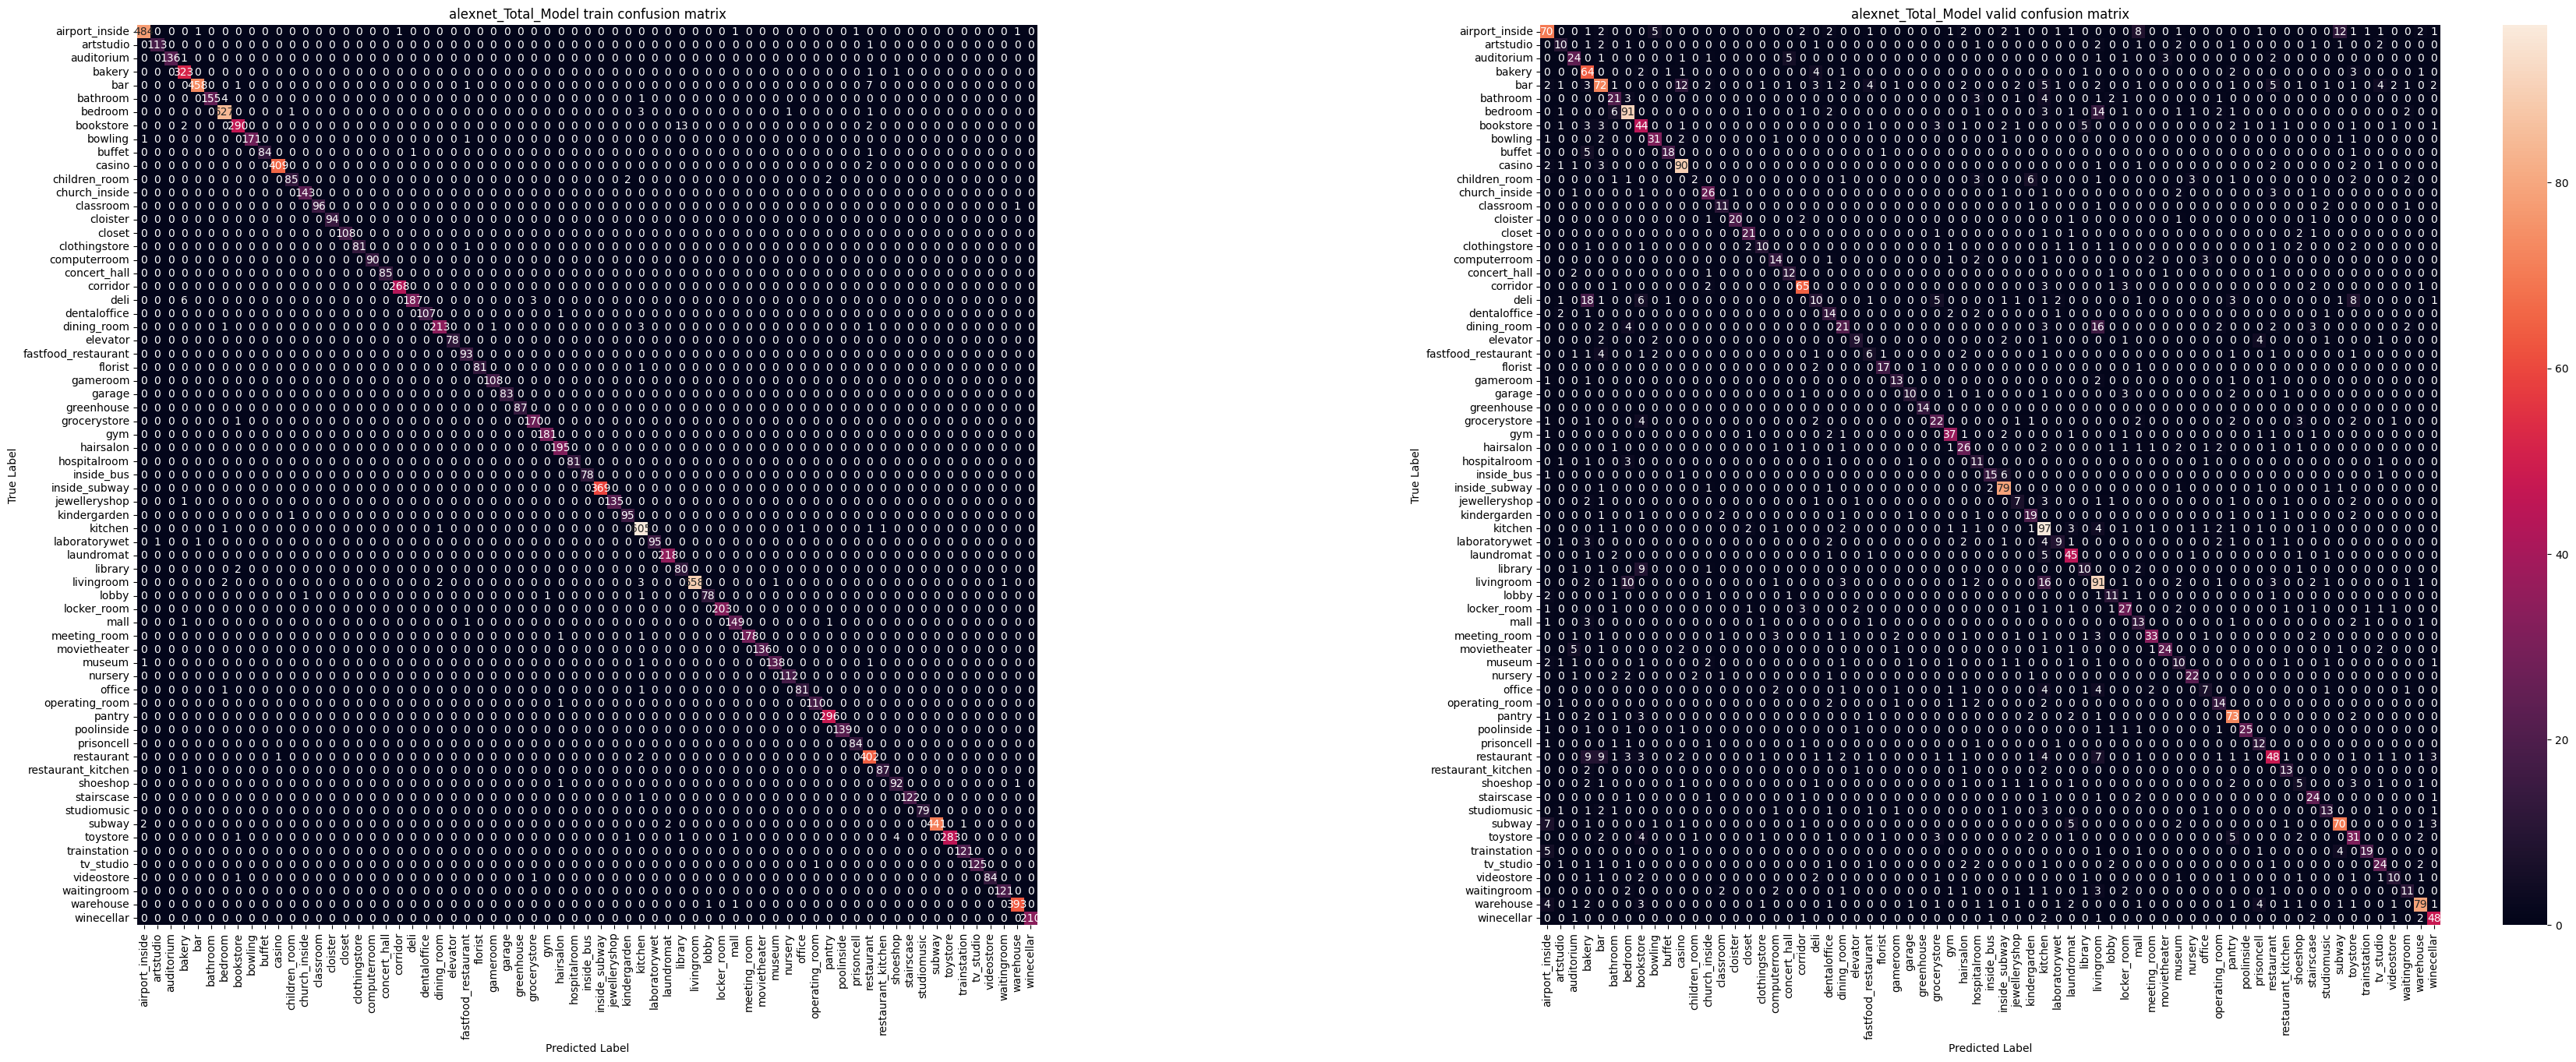

In [38]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

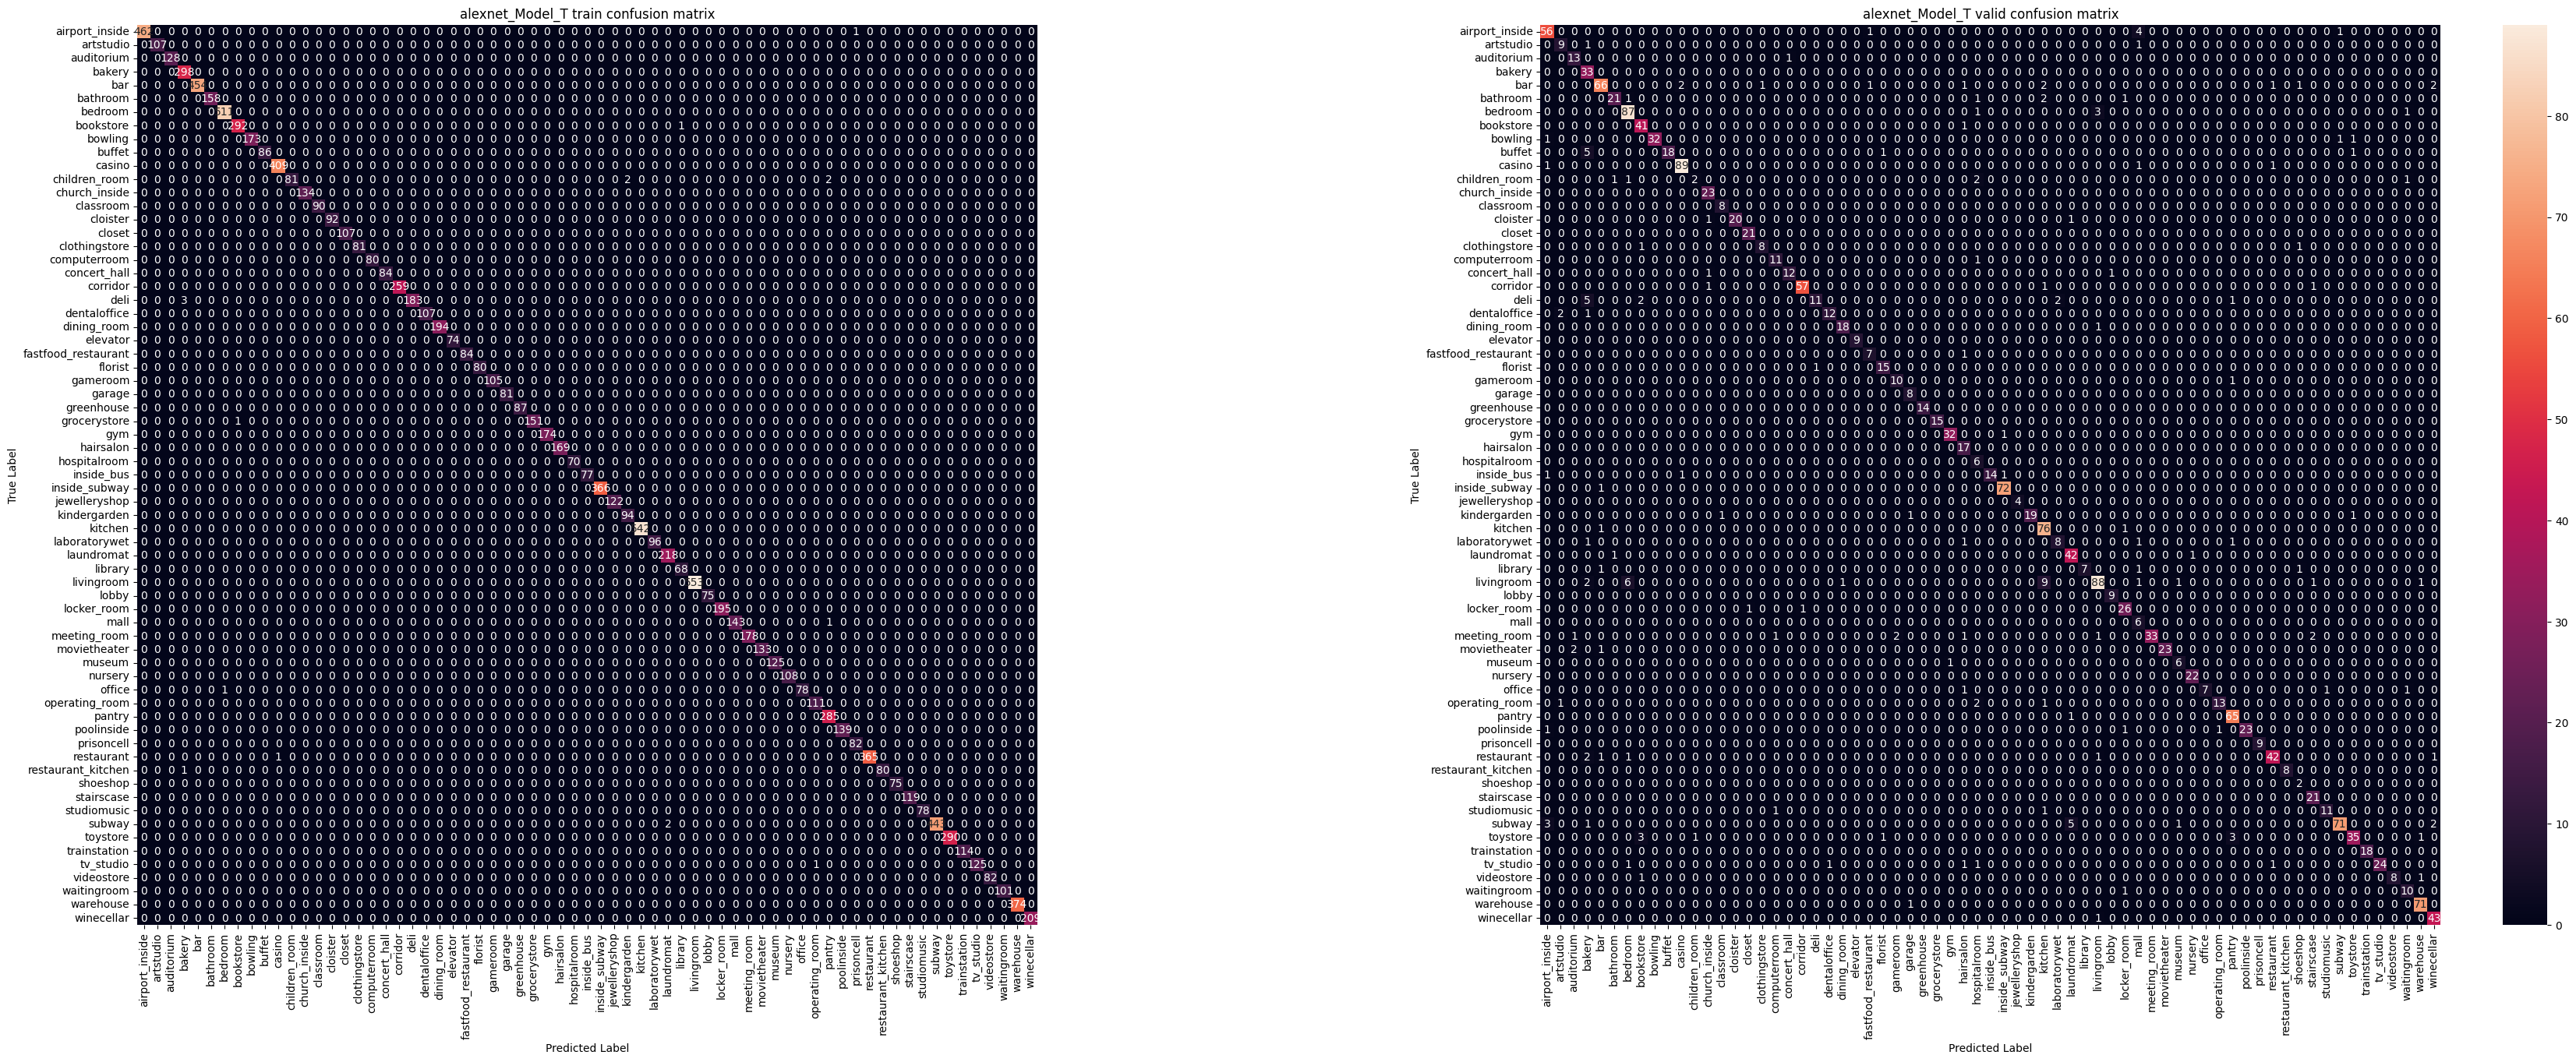

In [39]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

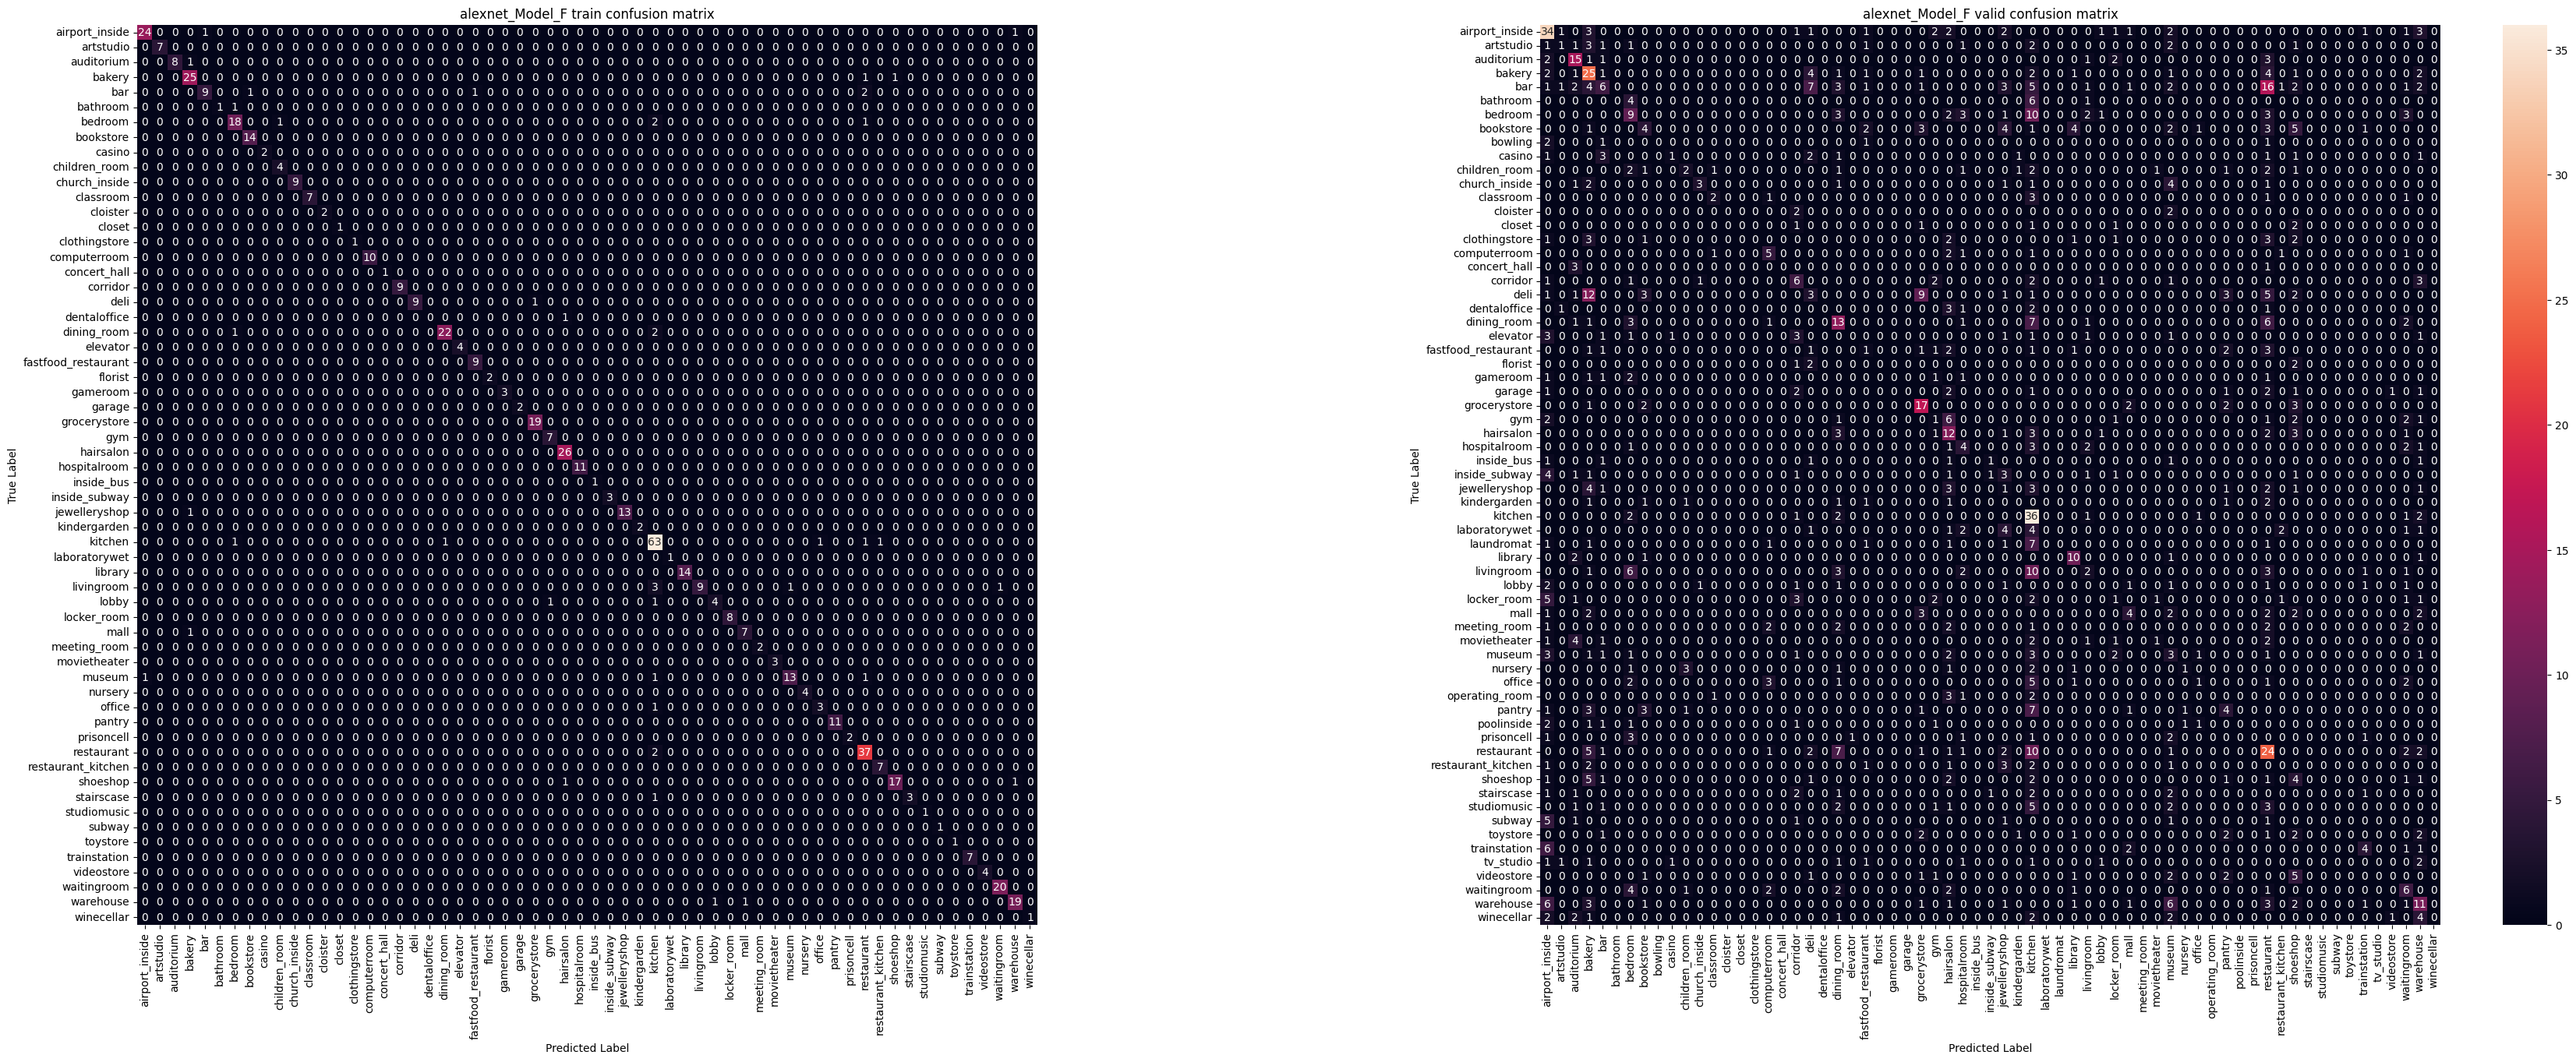

In [40]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [41]:
#全部模型裝在一起的表現
def show_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                pred_F=torch.max(model_F(d.unsqueeze(0)), dim = 1).indices.item()
                pred_T=torch.max(model_T(d.unsqueeze(0)), dim = 1).indices.item()
                pred_0=torch.max(model_0(d.unsqueeze(0)), dim = 1).indices.item()
                
                    # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item()
                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [42]:
def calculate_zscore(softmax,avg,max_softmax,min_softmax):
    return (softmax-avg)/(max_softmax-min_softmax)

In [43]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [44]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,13680,59,0,59,59,0.810082,0.999563,0.970046,1.000000,False,True,True,True,True
1,6270,25,20,25,25,0.247518,0.996064,0.967038,0.999930,False,True,True,True,True
2,10413,43,31,43,43,0.155310,0.996247,0.980616,0.999887,False,True,True,True,True
3,14530,62,43,62,62,0.205472,0.999981,0.999779,0.844803,False,True,True,True,True
4,14397,61,65,61,61,0.346374,0.986307,0.951815,0.999997,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12491,4286,12,47,12,12,0.263865,0.999957,0.985930,0.999991,False,True,True,True,True
12492,4769,16,65,16,16,0.446104,0.982110,0.988661,0.999993,False,True,True,True,True
12493,14557,62,4,62,62,0.327852,0.998903,0.997044,0.998717,False,True,True,True,True
12494,10088,41,6,41,41,0.389946,0.999556,0.990066,0.999961,False,True,True,True,True


In [45]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

7     19
54    12
60     8
4      7
44     7
20     6
5      4
41     4
22     4
0      3
59     3
31     3
40     3
63     3
3      3
10     2
45     2
13     2
38     2
37     2
8      2
25     2
6      2
9      2
29     2
36     1
1      1
24     1
42     1
16     1
51     1
17     1
47     1
50     1
30     1
35     1
Name: Target, dtype: int64

In [46]:
df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.85)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
485,13970,60,56,60,60,0.092338,0.995002,0.220219,0.542092,False,True,True,False,True
530,5447,20,29,20,20,0.549033,0.999819,0.826610,0.726217,False,True,True,False,True
580,2038,5,37,5,5,0.465355,0.967210,0.448645,0.731385,False,True,True,False,True
633,9043,38,1,38,38,0.156063,0.998550,0.608337,0.734892,False,True,True,False,True
869,7232,31,31,31,31,0.874793,0.987589,0.553223,0.557785,True,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11965,3148,7,40,7,7,0.463425,0.999928,0.980886,0.617004,False,True,True,False,True
12216,3159,7,40,7,7,0.976270,0.986809,0.909856,0.647931,False,True,True,False,True
12272,3398,9,54,9,9,0.380667,0.998981,0.996676,0.773939,False,True,True,False,True
12280,6320,25,25,25,25,0.756933,0.999992,0.688173,0.706681,True,True,True,False,True


In [47]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
10,311,0,0,0,0,0.585871,0.998544,0.889505,0.946191,True,True,True,False,True
267,3146,7,54,7,7,0.232634,0.995696,0.541416,0.911288,False,True,True,False,True
380,13794,59,61,59,59,0.729445,0.990190,0.658472,0.999927,False,True,True,False,True
437,3085,7,40,7,7,0.918649,0.986750,0.609737,0.988114,False,True,True,False,True
485,13970,60,56,60,60,0.092338,0.995002,0.220219,0.542092,False,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12044,2050,5,6,5,5,0.727214,0.993581,0.883673,0.996545,False,True,True,False,True
12216,3159,7,40,7,7,0.976270,0.986809,0.909856,0.647931,False,True,True,False,True
12272,3398,9,54,9,9,0.380667,0.998981,0.996676,0.773939,False,True,True,False,True
12280,6320,25,25,25,25,0.756933,0.999992,0.688173,0.706681,True,True,True,False,True


In [48]:
df_results[df_results['Softmax_F'] >df_results['Softmax_T']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
102,10079,41,41,4,62,0.442597,0.423541,0.576308,0.999953,True,False,False,False,False
260,7385,32,32,50,50,0.734515,0.543431,0.667244,0.996457,True,False,False,False,False
304,2618,6,6,6,41,0.658626,0.590892,0.487309,0.999940,True,True,False,False,False
362,4150,12,12,66,66,0.879142,0.723154,0.503156,0.999993,True,False,False,False,False
368,5934,22,22,62,62,0.678387,0.346550,0.674885,0.999916,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12177,9487,40,40,7,7,0.997752,0.966164,0.817566,0.999976,True,False,False,False,False
12366,7360,32,32,6,6,0.608884,0.451279,0.401846,0.997956,True,False,False,False,False
12411,6211,24,24,3,44,0.607735,0.428450,0.283204,0.999995,True,False,False,False,False
12420,10488,43,43,30,30,0.502947,0.480509,0.607753,0.999999,True,False,False,False,False


In [49]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,852,2,0,2,2,0.794928,0.998906,0.947914,0.999439,False,True,True,True,True
1,5532,20,3,3,9,0.754131,0.997644,0.388233,0.999993,False,False,False,True,False
2,3326,8,0,34,34,0.463250,0.570342,0.253331,0.999746,False,False,False,True,False
3,13549,59,0,59,59,0.554455,0.995685,0.984871,1.000000,False,True,True,True,True
4,14997,65,65,27,65,0.765283,0.975799,0.738032,0.999996,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3119,8631,37,37,37,39,0.940332,0.985636,0.603655,0.999969,True,True,False,True,False
3120,250,0,61,0,0,0.213360,0.804518,0.760434,0.999607,False,True,True,True,True
3121,10443,43,37,35,35,0.333134,0.643300,0.405344,0.986052,False,False,False,True,False
3122,11313,47,0,0,0,0.213621,0.600639,0.401853,0.993753,False,False,False,True,False


In [50]:
df=(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

4     58
54    57
0     55
3     44
37    41
      ..
8      6
15     5
25     5
14     4
18     3
Name: Target, Length: 65, dtype: int64

In [51]:
df_results_v[df_results_v['Decision']!=df_results_v['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
1,5532,20,3,3,9,0.754131,0.997644,0.388233,0.999993,False,False,False,True,False
2,3326,8,0,34,34,0.463250,0.570342,0.253331,0.999746,False,False,False,True,False
7,2919,7,40,7,60,0.183589,0.922527,0.470715,0.527125,False,True,False,True,False
8,8081,35,31,37,37,0.245236,0.976708,0.420866,0.898850,False,False,False,True,False
9,3531,10,4,4,4,0.320621,0.981850,0.831774,0.999910,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3118,1272,3,20,60,60,0.337208,0.380620,0.760838,0.999928,False,False,False,True,False
3119,8631,37,37,37,39,0.940332,0.985636,0.603655,0.999969,True,True,False,True,False
3121,10443,43,37,35,35,0.333134,0.643300,0.405344,0.986052,False,False,False,True,False
3122,11313,47,0,0,0,0.213621,0.600639,0.401853,0.993753,False,False,False,True,False
